---
### 3-1. 데이터 분석 보고서 만들기 실습 (따릉이, 2025년 12월)
---

In [1]:
# pkg's 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

#!pip install koreanize_matplotlib
import koreanize_matplotlib

In [2]:
# data loading 
df = pd.read_csv('data/서울특별시 공공자전거 대여이력 정보_2512.csv', encoding='cp949')
print(df.shape)
df.head().T

(1965170, 17)


,0,1,2,3,4
자전거번호,SPB-64783,SPB-64275,SPB-37686,SPB-69829,SPB-59846
대여일시,2025-12-01 00:00:59,2025-12-01 00:01:52,2025-12-01 00:01:29,2025-12-01 00:00:35,2025-12-01 00:00:06
대여 대여소번호,5084,5151,3651,4031,230
대여 대여소명,강서우체국,진넥스베르디엠 앞,개포동역 4번출구,청암예술학교 앞,영등포구청역 7번출구
대여거치대,0,0,0,0,0
반납일시,2025-12-01 00:03:22,2025-12-01 00:03:45,2025-12-01 00:04:04,2025-12-01 00:04:19,2025-12-01 00:04:21
반납대여소번호,01166,03516,02431,02920,\N
반납대여소명,강서구립등빛도서관,구의아리수정수센터앞,대치역 7번출구,상계중학교(당현2교사거리),\N
반납거치대,0,0,0,0,\N
이용시간(분),2,1,2,3,4


In [3]:
# \N, \\N : 결측치 표시 -> NaN으로 변경 
df = df.replace(r'\N', np.nan)
df = df.replace(r'\\N', np.nan)
df.head().T

,0,1,2,3,4
자전거번호,SPB-64783,SPB-64275,SPB-37686,SPB-69829,SPB-59846
대여일시,2025-12-01 00:00:59,2025-12-01 00:01:52,2025-12-01 00:01:29,2025-12-01 00:00:35,2025-12-01 00:00:06
대여 대여소번호,5084,5151,3651,4031,230
대여 대여소명,강서우체국,진넥스베르디엠 앞,개포동역 4번출구,청암예술학교 앞,영등포구청역 7번출구
대여거치대,0,0,0,0,0
반납일시,2025-12-01 00:03:22,2025-12-01 00:03:45,2025-12-01 00:04:04,2025-12-01 00:04:19,2025-12-01 00:04:21
반납대여소번호,01166,03516,02431,02920,NaN
반납대여소명,강서구립등빛도서관,구의아리수정수센터앞,대치역 7번출구,상계중학교(당현2교사거리),NaN
반납거치대,0,0,0,0,NaN
이용시간(분),2,1,2,3,4


In [4]:
# data type 확인
print(df.info())

# 전처리 대상 
# 대여일시, 반납일시 --> datetime 
# 생년 -> Int64 
df['대여일시'] = pd.to_datetime(df['대여일시'])
df['반납일시'] = pd.to_datetime(df['반납일시'])
df['생년'] = df['생년'].astype('Int64')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1965170 entries, 0 to 1965169
Data columns (total 17 columns):
 #   Column    Dtype  
---  ------    -----  
 0   자전거번호     object 
 1   대여일시      object 
 2   대여 대여소번호  int64  
 3   대여 대여소명   object 
 4   대여거치대     int64  
 5   반납일시      object 
 6   반납대여소번호   object 
 7   반납대여소명    object 
 8   반납거치대     object 
 9   이용시간(분)   int64  
 10  이용거리(M)   float64
 11  생년        object 
 12  성별        object 
 13  이용자종류     object 
 14  대여대여소ID   object 
 15  반납대여소ID   object 
 16  자전거구분     object 
dtypes: float64(1), int64(3), object(13)
memory usage: 254.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1965170 entries, 0 to 1965169
Data columns (total 17 columns):
 #   Column    Dtype         
---  ------    -----         
 0   자전거번호     object        
 1   대여일시      datetime64[ns]
 2   대여 대여소번호  int64         
 3   대여 대여소명   object        
 4   대여거치대     int64         
 5   반납일시      datetime64[ns]
 6   반납대여소번호   object      

In [5]:
# 1. '25.12월 현재 자전거 대수는? 
df['자전거번호'].nunique()

38892

In [6]:
# 2. 총 대여소 개수는? 
df['대여 대여소번호'].nunique()

2770

In [7]:
# 1대당 평균 대여횟수 
len(df) / df['자전거번호'].nunique()

50.52890054509925

성별
M    0.678233
F    0.321767
Name: proportion, dtype: float64


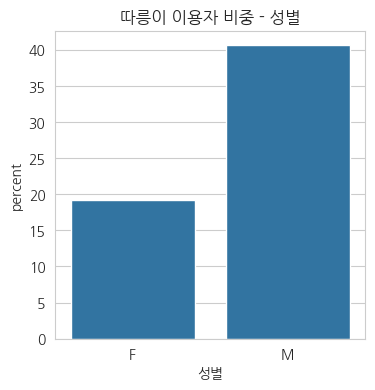

In [8]:
# 3. 이용자의 성별 비율은? 
sex_map = {
    'M': 'M', 'F':'F', 
    'm':'M', 'f':'F'
}
df['성별'] = df['성별'].map(sex_map)

print(df['성별'].value_counts(normalize = True))

plt.figure(figsize=(4,4))
sns.countplot(data=df, x='성별', stat='percent')
plt.title('따릉이 이용자 비중 - 성별')
plt.show()

연령대
10대         NaN
20대    0.201286
30대    0.229640
40대    0.151728
50대    0.108911
60대    0.039721
70대         NaN
80대         NaN
Name: proportion, dtype: float64


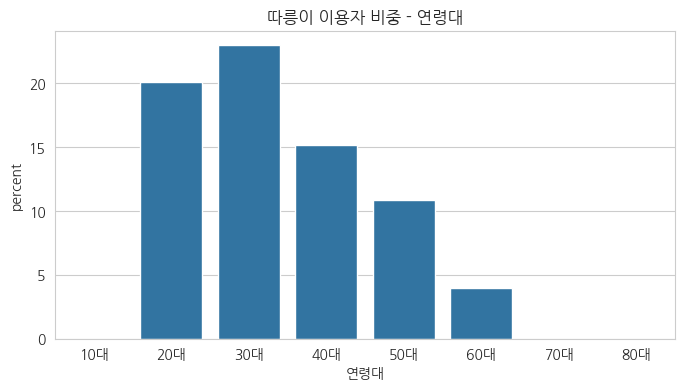

In [9]:
# 4. 이용자의 연령대별 비중은? 
df['연령'] = 2025 - df['생년']

def age_gen(x):
    if pd.isnull(x):
        return '미상'
    elif x < 20:
        return '10대 이하'
    elif x < 30:
        return '20대'
    elif x < 40:
        return '30대'
    elif x < 50:
        return '40대'
    elif x < 60:
        return '50대'
    elif x < 70:
        return '60대'
    else:
        return '70대 이상'

df['연령대'] = df['연령'].apply(age_gen)
#df.head().T

age_order = ['10대','20대','30대','40대','50대','60대','70대','80대']
print(df['연령대'].value_counts(normalize=True).reindex(age_order))

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='연령대', stat='percent', order=age_order)
plt.title('따릉이 이용자 비중 - 연령대')
plt.show()

In [10]:
# 5. 비회원 이용자는 얼마나 되는가? 
print(df['이용자종류'].value_counts(), '\n') 
print(df['이용자종류'].value_counts(normalize=True)) 

이용자종류
내국인    1639115
비회원       2392
Name: count, dtype: int64 

이용자종류
내국인    0.998543
비회원    0.001457
Name: proportion, dtype: float64


자전거구분
일반자전거    1945029
새싹자전거      20141
Name: count, dtype: int64 

자전거구분
일반자전거    0.989751
새싹자전거    0.010249
Name: proportion, dtype: float64


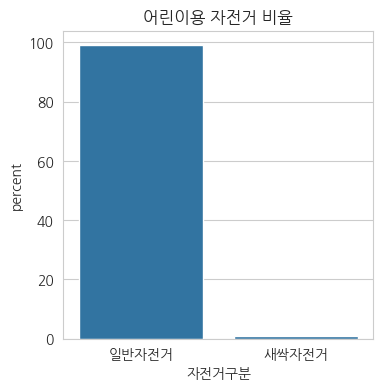

In [11]:
# 6. 어린이용 자전거는 얼마나 있나? 
print(df['자전거구분'].value_counts(), '\n') 
print(df['자전거구분'].value_counts(normalize=True)) 

plt.figure(figsize=(4,4))
sns.countplot(data=df, x='자전거구분', stat='percent')
plt.title('어린이용 자전거 비율')
plt.show()

In [12]:
# 7. 대여 1회당 평균 이용시간과 이용거리는 
print('1회 평균 이용시간(분) = ', 
      round(df['이용시간(분)'].mean(), 1)
      )

print('1회 평균 이용거리(km) = ', 
      round(df['이용거리(M)'].mean() / 1000, 1)
      )

1회 평균 이용시간(분) =  17.8
1회 평균 이용거리(km) =  1.8


In [13]:
# 8. 대여가 가장 많이 발생한 대여소는? 
#df.groupby('대여 대여소명').size().sort_values(ascending=False)[:1]
df.groupby('대여 대여소명')['대여일시'].count().sort_values(ascending=False)[:1]

대여 대여소명
마곡나루역 2번 출구    9540
Name: 대여일시, dtype: int64

In [14]:
# 9. 반대로 대여가 가장 적게 발생한 대여소는? 
df.groupby('대여 대여소명').size().sort_values()[:1]

대여 대여소명
봉은사역6번출구(현대아이파크타워앞)    1
dtype: int64

In [15]:
# 10. 가장 장시간 대여한 건은? 
ans = df[df['이용시간(분)'] == df['이용시간(분)'].max()]
ans.T

,1771911
자전거번호,SPB-73198
대여일시,2025-12-28 01:11:00
대여 대여소번호,2222
대여 대여소명,사당역 12번출구 뒤
대여거치대,0
반납일시,2025-12-29 01:10:50
반납대여소번호,02036
반납대여소명,정금마을 마을버스정류장
반납거치대,0
이용시간(분),1439


가장 대여가 많았던 날 =  날짜
2025-12-01    101502
dtype: int64


가장 대여가 적었던 날 =  날짜
2025-12-13    19152
dtype: int64


<Axes: xlabel='날짜'>

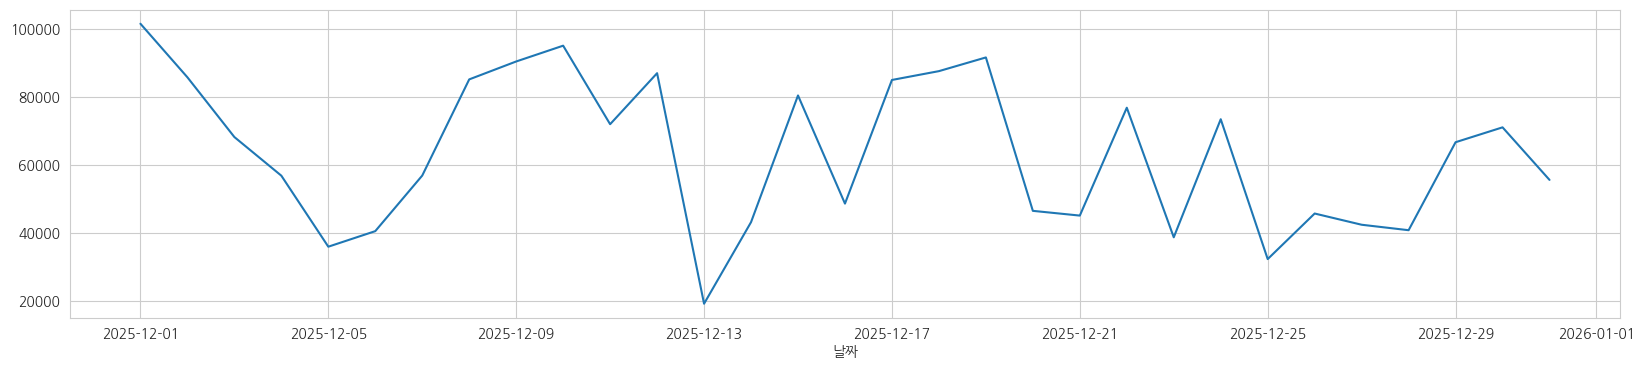

In [16]:
# 11. 날짜별 대여 건수 
df['날짜'] = df['대여일시'].dt.date

print('가장 대여가 많았던 날 = ', df.groupby('날짜').size().sort_values(ascending=False).head(1))
print('\n')
print('가장 대여가 적었던 날 = ', df.groupby('날짜').size().sort_values().head(1))

plt.figure(figsize=(20,4))
df.groupby('날짜').size().plot()

,요일,0
0,Monday,410487
1,Tuesday,334457
2,Wednesday,377163
3,Thursday,248594
4,Friday,260141
5,Saturday,148497
6,Sunday,185831


<Axes: xlabel='요일', ylabel='0'>

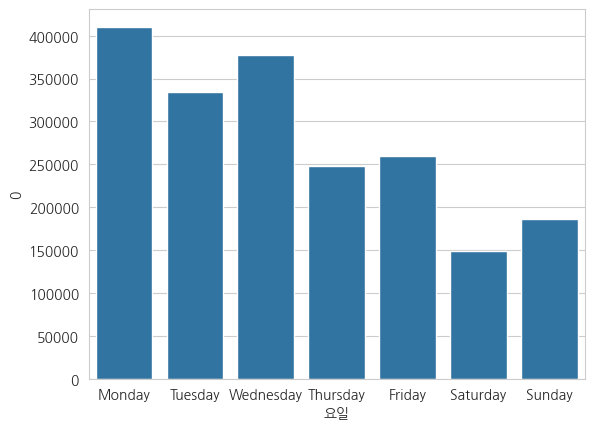

In [17]:
# 12. 어떤 요일에 많이 대여하나? 
df['요일'] = df['대여일시'].dt.day_name()

week_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

data = df.groupby('요일').size().reindex(week_order)
data = data.reset_index()
display(data) 

sns.barplot(data=data, x='요일', y=0)

---
- 서울시에서 집계한 '25.12월 따릉이 이용통계를 살펴보면 12월 현재 기준 2,770곳의 대여소에서 총 38,892대의 자전거가 운용되고 있다. 
- 12월중 따릉이 총 대여건수는 1,965,170건이며 이는 운용중인 자전거 한대당 약 50.5회 대여 되었음을 의미한다. 
- 이용회원 비중은 남자가 약 67%로 여자(약 32%)에 비해 두배이상 높았으며, 연령대별로는 20대와 30대가 각각 약 20%, 23%로 가장 많았다. 
- 따릉이 1회 대여시 평균 이용시간은 약 18분, 이동거리는 약 1.8km로 나타났다. 
  
- 서울시는 일반 자전거 외에 어린이용 "새싹자건거"도 운영하고 있는데, 어린이용 자전거는 20,141대로 아직까지 전체의 0.1% 수준에 불과하다. 
- 한편 따릉이는 반드시 회원가입을 하지 않아도 이용이 가능하지만, 12월 이용자 중 비회원은 23,92명(약 0.1%)로 거의 대부분이 회원가입후 이용하고 있는 것으로 나타났다. 
  
- 12월에 가장 대여가 많았던 대여소는 "마곡나루역 2번 출구" 대여소로 총 9,540건의 대여가 발생하였다. 
- 반면 가장 적었던 곳은 "봉은사역6번출구(현대아이파크타워앞)" 대여소로 단 1건만 대여된 것으로 나타났다. 

- 12월중 대여건수가 가장 많았던 날은 12월 1일로 하루동안 101,502건이 대여되었으며, 반면 12월 13일 19,152건으로 대여건수가 가장 적었다. 
- 요일별로 살펴보면 주초인 월~수요일에 30~40만건 수준으로 대여건수가 많았다가 차츰 줄어들어, 주말에는 15~20만건 수준이다. 
---

#### Advancded analysis
- 주중/주말과 시간대별 분석 추가 
- 12월 일자별 날씨 데이터 결합하여, 기온/습도 등에 따른 대여량 비교 

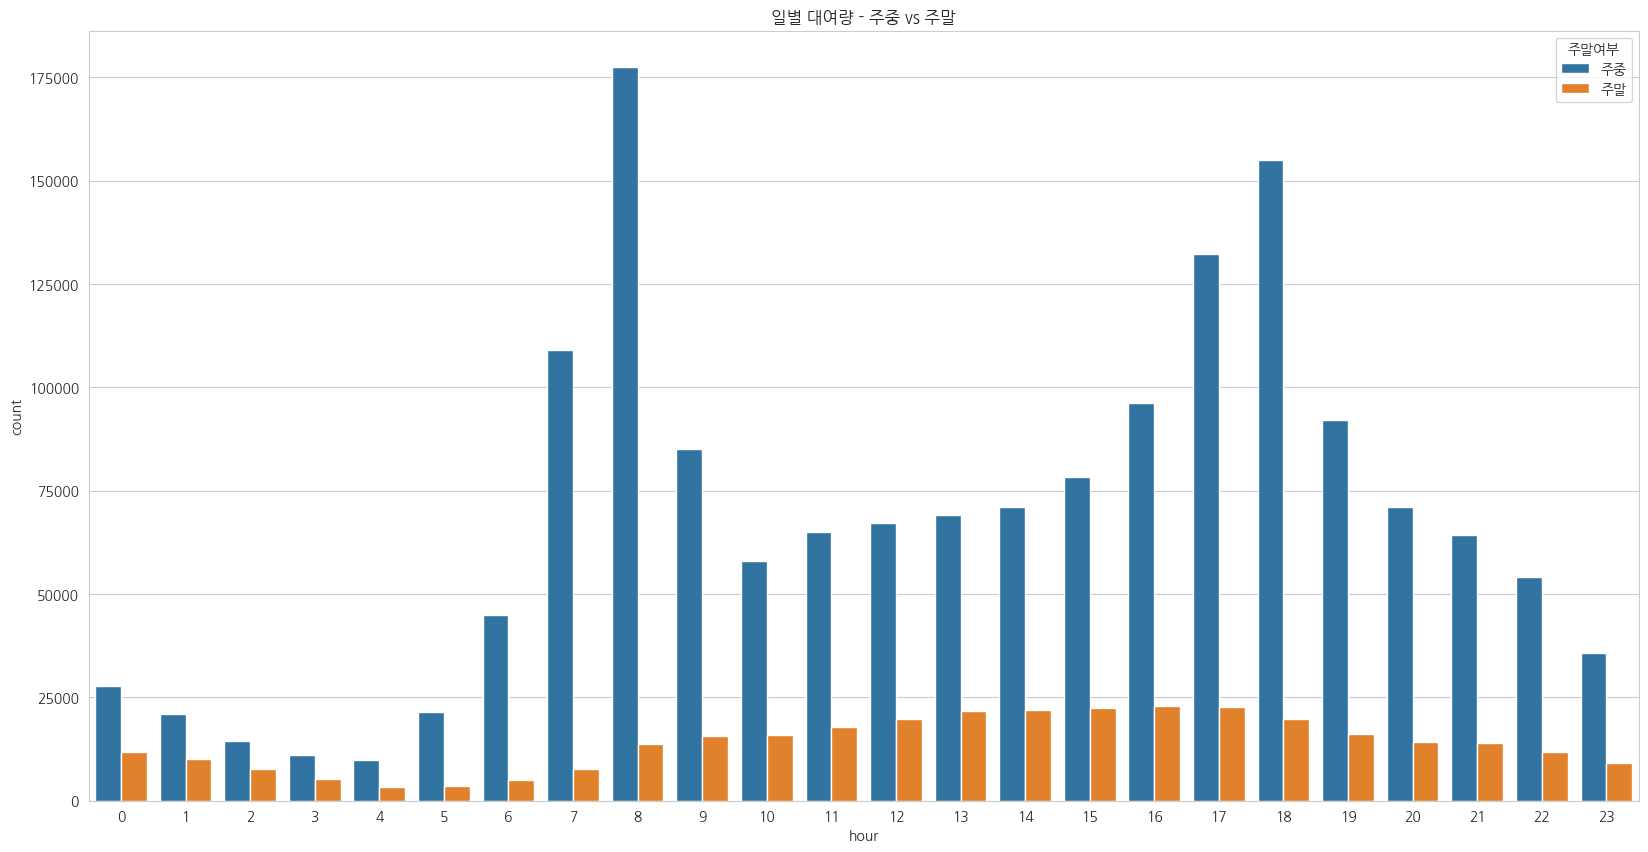

In [18]:
# 시간대별 대여량 
df['hour'] = df['대여일시'].dt.hour

def week_end(x): 
    if x == 'Saturday': 
        return '주말'
    elif x == 'Sunday': 
        return '주말'
    else: 
        return '주중'

df['주말여부'] = df['요일'].apply(week_end)

plt.figure(figsize=(20,10))
sns.countplot(data=df, x='hour', hue='주말여부')
plt.title('일별 대여량 - 주중 vs 주말')
plt.show()

In [19]:
# 날씨데이터 결합 
weather = pd.read_csv('data/weather_202512.csv')
display(weather.head())
weather.info()

,date,temp,rain,wind,humidity,cloud,sun,weather
0,2025-12-01,5.5,0.0,3.1,51.0,0.8,9.1,맑음
1,2025-12-02,0.1,0.0,3.5,41.0,2.1,8.5,맑음
2,2025-12-03,-6.0,0.0,3.2,41.0,0.6,8.4,맑음
3,2025-12-04,-3.2,4.0,2.2,50.0,1.4,8.7,맑음/눈/비/천둥번개
4,2025-12-05,-2.6,0.0,1.9,54.0,1.8,9.1,맑음


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      31 non-null     object 
 1   temp      31 non-null     float64
 2   rain      31 non-null     float64
 3   wind      31 non-null     float64
 4   humidity  31 non-null     float64
 5   cloud     31 non-null     float64
 6   sun       31 non-null     float64
 7   weather   31 non-null     object 
dtypes: float64(6), object(2)
memory usage: 2.1+ KB


In [20]:
# date, 날짜 컬럼 datetime 타입으로 변환 
weather['date'] = pd.to_datetime(weather['date'])
df['날짜'] = pd.to_datetime(df['날짜'])

# df와 weather 결합 
df_new = pd.merge(df, weather, left_on='날짜', right_on='date', how='left')
df_new.head().T


,0,1,2,3,4
자전거번호,SPB-64783,SPB-64275,SPB-37686,SPB-69829,SPB-59846
대여일시,2025-12-01 00:00:59,2025-12-01 00:01:52,2025-12-01 00:01:29,2025-12-01 00:00:35,2025-12-01 00:00:06
대여 대여소번호,5084,5151,3651,4031,230
대여 대여소명,강서우체국,진넥스베르디엠 앞,개포동역 4번출구,청암예술학교 앞,영등포구청역 7번출구
대여거치대,0,0,0,0,0
반납일시,2025-12-01 00:03:22,2025-12-01 00:03:45,2025-12-01 00:04:04,2025-12-01 00:04:19,2025-12-01 00:04:21
반납대여소번호,01166,03516,02431,02920,NaN
반납대여소명,강서구립등빛도서관,구의아리수정수센터앞,대치역 7번출구,상계중학교(당현2교사거리),NaN
반납거치대,0,0,0,0,NaN
이용시간(분),2,1,2,3,4


In [21]:
# 날씨별 분석 준비  
daily_cnt = (
    df_new.groupby('date')
          .agg(
              rental_cnt=('자전거번호','count'),
              temp=('temp','first'),
              humidity=('humidity','first'),
              weather=('weather','first')   # 추가
          )
          .reset_index()
)

display(daily_cnt.head())

,date,rental_cnt,temp,humidity,weather
0,2025-12-01,101502,5.5,51.0,맑음
1,2025-12-02,85750,0.1,41.0,맑음
2,2025-12-03,68177,-6.0,41.0,맑음
3,2025-12-04,56810,-3.2,50.0,맑음/눈/비/천둥번개
4,2025-12-05,35922,-2.6,54.0,맑음


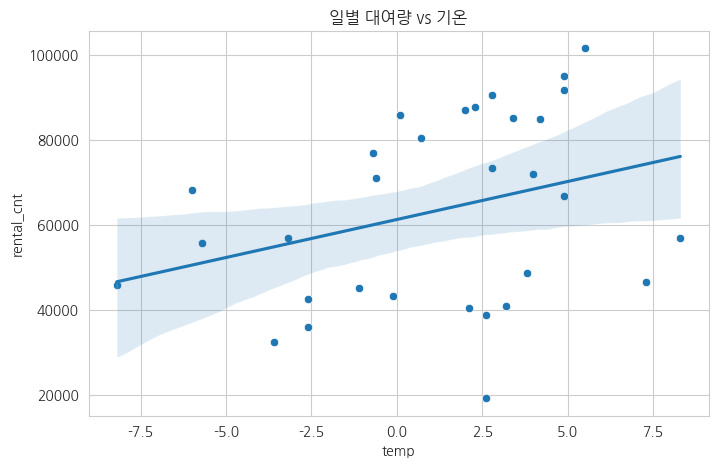

In [22]:
# 기온과 대여량 
plt.figure(figsize=(8,5))
sns.scatterplot(data=daily_cnt, x='temp', y='rental_cnt')

sns.regplot(
    data=daily_cnt,
    x='temp',
    y='rental_cnt',
    scatter=False
)

plt.title('일별 대여량 vs 기온')
plt.show()

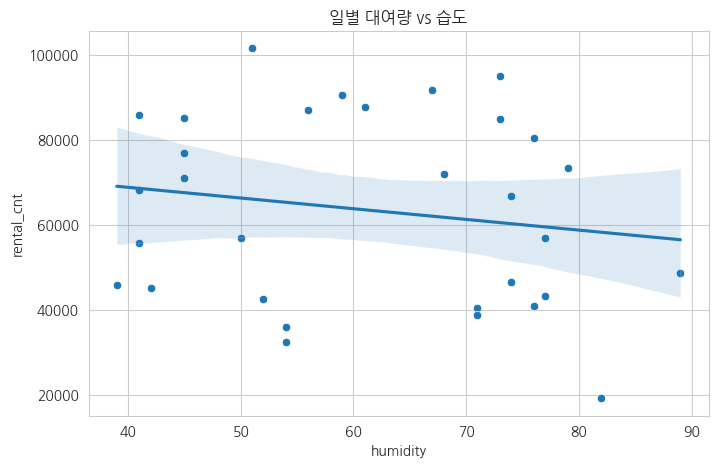

In [23]:
# 습도과 대여량 
plt.figure(figsize=(8,5))
sns.scatterplot(data=daily_cnt, x='humidity', y='rental_cnt')

sns.regplot(
    data=daily_cnt,
    x='humidity',
    y='rental_cnt',
    scatter=False
)

plt.title('일별 대여량 vs 습도')
plt.show()

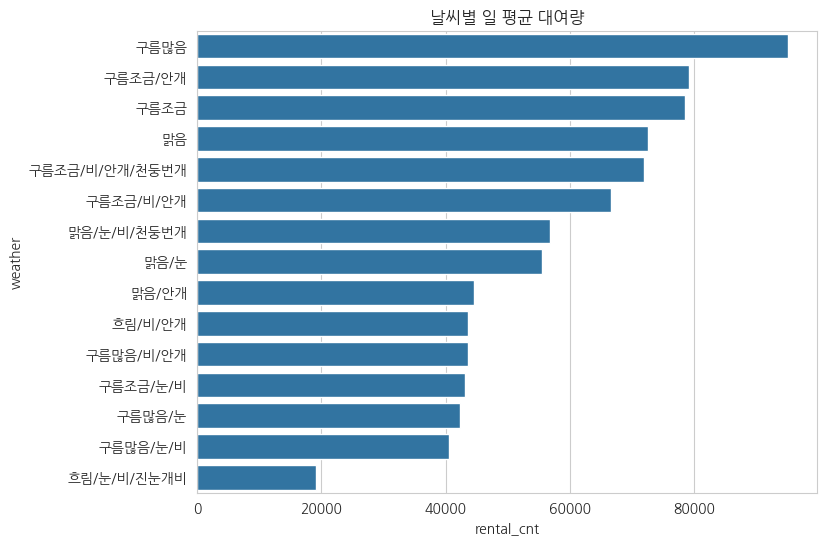

In [26]:
# 날씨구분별 평균 대여량 비교 
weather_avg = daily_cnt.groupby('weather')['rental_cnt'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,6))
sns.barplot(
    data=weather_avg,
    y='weather',
    x='rental_cnt'
)

plt.title('날씨별 일 평균 대여량')
plt.show()